# Forecasting tomorrow's electricity price in Stockholm (SE3)

Every day at noon, Nord Pool's day-ahead auction sets the electricity price for each hour of the next day. This notebook walks through how well those prices can be forecast the morning before, using only public data: past prices from [elprisetjustnu.se](https://www.elprisetjustnu.se/elpris-api) and weather from [SMHI](https://opendata.smhi.se/) and [Open-Meteo](https://open-meteo.com/).

It reads the small files in `data/processed/`. The pipeline that creates them is in `src/se3forecast/` (see the README).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from se3forecast import PROCESSED
from se3forecast import figures  # applies the shared chart style

pd.set_option("display.precision", 2)
hourly = pd.read_parquet(PROCESSED / "hourly.parquet")
hourly.tail(3)

,date,hour,se1,se2,se3,se4,se3_ore_kwh,temp_sthlm,wind_index,temp_sthlm_fc,wind_index_fc
43221,2026-10-06,21,1.61,1.32,109.39,224.11,122.99,NaN,NaN,11.6,5.76
43222,2026-10-06,22,1.04,2.41,100.81,196.74,113.34,NaN,NaN,11.2,5.57
43223,2026-10-06,23,0.95,2.48,99.09,194.85,111.42,NaN,NaN,10.9,5.50


## 1. The data

One row per delivery date and local hour. Since 1 October 2025 the auction clears every 15 minutes; those prices are averaged to the hour so the whole history has one resolution. The weather columns are Stockholm's temperature and a *wind index*, the mean wind speed at six SMHI stations near Sweden's main wind farms. The `_fc` columns hold the same two values as they were *forecast* before the auction (from 2024).

In [2]:
print(f"{hourly['date'].min():%Y-%m-%d} to {hourly['date'].max():%Y-%m-%d}, {len(hourly):,} hours")
hourly.groupby(hourly["date"].dt.year)[["se1", "se2", "se3", "se4"]].mean()

2021-11-01 to 2026-10-06, 43,224 hours


,se1,se2,se3,se4
date,,,,
2021,54.12,54.12,129.84,147.49
2022,59.06,61.92,129.21,152.11
2023,39.97,39.98,51.70,64.88
2024,25.06,24.65,35.78,49.72
2025,16.71,16.53,46.24,60.43
2026,43.92,45.24,70.33,88.58


SE3 prices in 2022 averaged almost twice the 2026 level and nearly four times the 2024 level, because of the gas crisis. A model trained on that period has to cope with a very different price level, which is why the models work on an `asinh` scale (like a log, but it allows the negative prices that now appear on windy, sunny days).

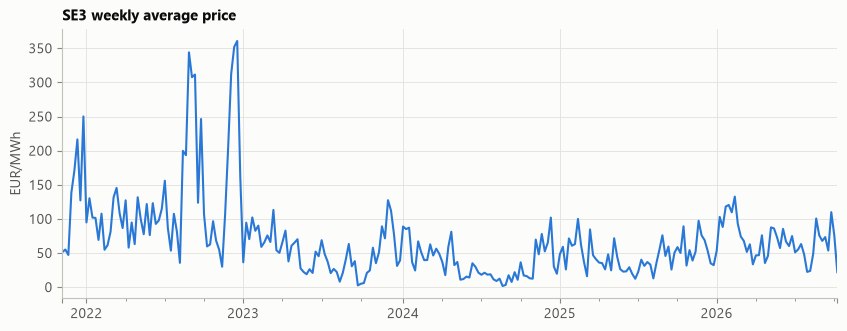

negative-price hours per year:


date
2022     29
2023    428
2024    651
2025    345
2026     79
dtype: int64

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.5))
hourly.set_index("date")["se3"].resample("W").mean().plot(ax=ax, color=figures.SERIES[0], lw=1.5)
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("")
ax.set_title("SE3 weekly average price")
plt.show()
print("negative-price hours per year:")
hourly[hourly["se3"] < 0].groupby(hourly["date"].dt.year).size()

## 2. The forecasting setup

The forecast for day *T* is made on the morning of *T-1*, before bids close at 12:00. At that moment all prices up to the end of *T-1* are known (they were set the day before), but nothing about *T*. So every price feature is lagged by at least one day, and `tests/test_features.py` checks this by changing the target day's prices and asserting the features do not move.

Weather is the subtle part. Observed weather for *T* is not known on *T-1*, so using it in a backtest would leak information. Instead, the backtest uses archived forecasts from Open-Meteo's previous-runs API: the 24-hour-old forecast for hours 00-11 (it existed before noon) and the 48-hour-old forecast for hours 12-23.

In [4]:
from se3forecast.features import CALENDAR_FEATURES, PRICE_FEATURES, WEATHER_FEATURES, make_features

feats = make_features(hourly, "forecast")
print(len(PRICE_FEATURES + CALENDAR_FEATURES + WEATHER_FEATURES), "core features, plus all 24 prices of the days 1, 2, 3 and 7 back")
feats.loc[feats["date"] == "2026-01-20", ["date", "hour", "y", "p_lag1", "p_lag7", "d1_mean", "wind", "temp"]].head(8)

31 core features, plus all 24 prices of the days 1, 2, 3 and 7 back


,date,hour,y,p_lag1,p_lag7,d1_mean,wind,temp
36984,2026-01-20,0,111.16,91.32,72.23,135.21,2.02,-0.7
36985,2026-01-20,1,110.75,89.67,69.52,135.21,2.03,-1.0
36986,2026-01-20,2,106.92,89.53,71.69,135.21,1.93,-0.5
36987,2026-01-20,3,106.46,89.18,69.96,135.21,1.88,-0.6
36988,2026-01-20,4,109.42,89.61,74.75,135.21,2.00,-1.2
36989,2026-01-20,5,121.00,93.26,78.88,135.21,2.03,-1.3
36990,2026-01-20,6,182.11,122.58,90.42,135.21,1.98,-1.1
36991,2026-01-20,7,236.80,155.93,113.75,135.21,2.12,-1.2


In [5]:
both = hourly.dropna(subset=["wind_index", "wind_index_fc"])
print(f"Weather forecasts vs observations since {both['date'].min():%Y-%m}:")
for obs, fc in [("temp_sthlm", "temp_sthlm_fc"), ("wind_index", "wind_index_fc")]:
    print(f"  {obs:11s} correlation {both[obs].corr(both[fc]):.2f}, mean absolute difference {(both[obs] - both[fc]).abs().mean():.2f}")

Weather forecasts vs observations since 2024-01:
  temp_sthlm  correlation 0.98, mean absolute difference 1.09
  wind_index  correlation 0.88, mean absolute difference 0.57


## 3. Models

| Model | Idea |
|---|---|
| Naive | Same hour yesterday (same hour last week on Mondays and weekends). The standard benchmark from [Lago et al. (2021)](https://doi.org/10.1016/j.apenergy.2021.116983). |
| Same hour last week | A weekly seasonal naive forecast. |
| LEAR | One Lasso regression per hour on asinh-transformed prices of the last days, the other zones, weather and weekday. The linear benchmark in the price forecasting literature. |
| LightGBM | Gradient boosting over all hours, with price lags, yesterday's shape, calendar and weather. |
| Average | The plain mean of LEAR and LightGBM. |

All models are retrained at the start of every month on everything before it, then forecast every day of that month.

## 4. Choosing on the validation year

Choices such as the training window and whether to include the full 24-hour price profile were made on October 2024 to September 2025. The test year was run once those were fixed.

In [6]:
pd.read_csv(PROCESSED / "validation_metrics.csv", index_col="model")[["mae", "rmse", "rmae"]]

,mae,rmse,rmae
model,,,
Naive (yesterday / last week),26.35,42.39,1.00
"LEAR, 1-year window",16.63,28.44,0.63
"LEAR, 2-year window",16.09,28.01,0.61
"LEAR, all history",17.23,27.37,0.65
"LightGBM, 2-year window",17.25,28.92,0.66
"LightGBM, all history",17.12,27.42,0.65
"LightGBM, no weather",20.27,31.19,0.77
"LightGBM, + all 96 hourly lags",16.78,27.37,0.64
"LightGBM, raw prices (no asinh)",17.75,28.00,0.67


Weather cuts LightGBM's error from 20.3 to 17.1 EUR/MWh. LEAR does best on a two-year window (the crisis years hurt it), LightGBM on all history. Averaging the two beats either alone, so that is the final model.

## 5. Results on the test year (October 2025 to September 2026)

In [7]:
metrics = pd.read_csv(PROCESSED / "backtest_metrics.csv", index_col="model")
metrics[["mae", "rmse", "bias", "rmae"]]

,mae,rmse,bias,rmae
model,,,,
Naive (yesterday / last week),29.03,40.27,0.83,1.00
Same hour last week,36.56,50.30,-0.64,1.26
"LEAR (Lasso, one model per hour)",17.54,25.02,-5.95,0.60
"LightGBM, prices + calendar",20.22,28.68,-3.36,0.70
"LightGBM, prices + calendar + weather",17.03,24.55,-3.59,0.59
Average of LEAR and LightGBM,16.34,23.68,-4.77,0.56
Average of LEAR and LightGBM (observed weather),16.62,24.21,-5.39,0.57


The final model's mean absolute error is 16.3 EUR/MWh, 44% below the naive forecast. The average price in the test year was 67 EUR/MWh.

One surprise: feeding the model the weather that actually happened makes it slightly *worse* (16.6) than feeding it the forecasts. That makes sense once you remember that prices are set by bids, and bidders only know the forecast too.

In [8]:
preds = pd.read_parquet(PROCESSED / "backtest_predictions.parquet")
final = preds[preds["model"] == "Average of LEAR and LightGBM"].copy()
final["error"] = final["pred"] - final["y"]
final["price_decile"] = pd.qcut(final["y"], 10, labels=range(1, 11))
final.groupby("price_decile", observed=True).agg(mean_price=("y", "mean"), bias=("error", "mean"), mae=("error", lambda e: e.abs().mean()))

,mean_price,bias,mae
price_decile,,,
1,2.45,7.78,11.21
2,14.45,12.90,15.22
3,30.07,6.28,10.51
4,44.10,3.04,10.79
5,56.55,-1.28,11.17
6,69.68,-5.34,12.15
7,83.32,-9.35,14.98
8,97.23,-12.35,18.13
9,113.63,-16.26,22.26


The forecasts are pulled towards the middle: the cheapest hours are over-forecast and the most expensive 10% are under-forecast by 33 EUR/MWh on average. Spikes come from things the inputs do not see, such as a nuclear reactor going offline or tight import capacity.

## 6. Prediction intervals

The LightGBM quantile models give a 10th and a 90th percentile. Raw, that 80% interval only covered 64% of the actual prices, so it is widened by split conformal calibration on the last 90 days of each training set.

In [9]:
band = preds[preds["model"] == "LightGBM, prices + calendar + weather"]
inside = lambda lo, hi: band["y"].between(band[lo], band[hi]).mean()
print(f"raw quantile interval covers {inside('lo_raw', 'hi_raw'):.0%}, calibrated interval covers {inside('lo', 'hi'):.0%} (target 80%)")

raw quantile interval covers 64%, calibrated interval covers 80% (target 80%)


## 7. Is the improvement real?

One test year is a sample, so the differences above could partly be luck. `se3forecast.evaluation` runs three checks.

**Diebold-Mariano tests.** For each pair of models, take the daily mean absolute error of both and test whether the first is lower on average (one-sided, with the Harvey-Leybourne-Newbold correction). Each cell below is the p-value for "row is more accurate than column".

In [10]:
from se3forecast.evaluation import block_bootstrap, daily_loss, dm_matrix, interval_scores

loss = daily_loss(preds)
dm = dm_matrix(loss)
short = {m: s.replace(chr(10), " ") for m, s in figures.SHORT_NAMES.items()}
short["Average of LEAR and LightGBM (observed weather)"] = "Average, observed weather"
dm.rename(index=short, columns=short).round(3)

model,Naive,Last week,LEAR,"LightGBM, no weather",LightGBM,Average,"Average, observed weather"
model,,,,,,,
Naive,NaN,0.0,1.00,1.0,1.00,1.00,1.00
Last week,1.0,NaN,1.00,1.0,1.00,1.00,1.00
LEAR,0.0,0.0,NaN,0.0,0.92,1.00,1.00
"LightGBM, no weather",0.0,0.0,1.00,NaN,1.00,1.00,1.00
LightGBM,0.0,0.0,0.08,0.0,NaN,1.00,0.95
Average,0.0,0.0,0.00,0.0,0.00,NaN,0.04
"Average, observed weather",0.0,0.0,0.00,0.0,0.05,0.96,NaN


The average beats LEAR, LightGBM and the baselines (all p < 0.001), even though their mean errors differ by only 0.7 EUR/MWh: the test is paired, so it only needs the average to win consistently on the same days. LEAR and LightGBM on their own are not significantly different (p = 0.08). Forecast weather beats observed weather at p = 0.04, which is borderline given how many comparisons are in this table.

**Block bootstrap.** Resampling whole weeks of days gives confidence intervals for the error and for the improvement over naive:

In [11]:
block_bootstrap(loss).rename(index=short)

,mae,mae_low,mae_high,improvement,improvement_low,improvement_high
model,,,,,,
Naive,29.03,26.30,31.63,-0.00,0.00,0.00
Last week,36.56,33.06,40.04,-0.26,-0.36,-0.17
LEAR,17.54,16.04,18.90,0.40,0.34,0.45
"LightGBM, no weather",20.22,18.48,21.78,0.30,0.25,0.35
LightGBM,17.03,15.44,18.42,0.41,0.37,0.46
Average,16.34,14.85,17.67,0.44,0.39,0.48
"Average, observed weather",16.62,15.12,18.05,0.43,0.38,0.47


**Interval scores.** Coverage alone rewards wide intervals, so the intervals are also scored with pinball loss (for each quantile) and the Winkler interval score (width plus a penalty for every miss). The baseline is the naive forecast plus the 10th and 90th percentiles of its own errors over the previous year.

In [12]:
interval_scores(preds)

,coverage,mean_width,pinball_q10,pinball_q90,interval_score
Naive + past errors (historical simulation),0.75,83.00,7.35,7.34,146.88
"LightGBM quantiles, raw",0.64,41.14,3.70,4.96,86.53
"LightGBM quantiles, conformal",0.80,54.28,3.64,4.54,81.80


The calibrated interval reaches the target 80% coverage while being about a third narrower than the naive one, and it has the lowest pinball losses and interval score.

## 8. What is it good for?

Households with hourly contracts, EV chargers and heat pumps care most about *when* power is cheap. If you pick the three cheapest hours of each day using the forecast, you pay on average (EUR/MWh):

In [13]:
rows = []
for day, g in final.groupby("date"):
    rows.append({"day average": g["y"].mean(), "3 hours picked by forecast": g.nsmallest(3, "pred")["y"].mean(),
                 "3 truly cheapest hours": g.nsmallest(3, "y")["y"].mean()})
choice = pd.DataFrame(rows).mean()
print(choice.round(1).to_string())
print(f"share of the possible saving captured: {(choice.iloc[0] - choice.iloc[1]) / (choice.iloc[0] - choice.iloc[2]):.0%}")

day average                   67.1
3 hours picked by forecast    38.2
3 truly cheapest hours        34.5
share of the possible saving captured: 89%


## 9. Limitations

- **No fundamentals beyond weather.** Nuclear availability, hydro reservoir levels, gas prices and interconnector capacity drive SE3 prices but need data sources (ENTSO-E, Nord Pool market messages) that require registration. They would most likely help with spikes.
- **One temperature station and a simple wind index.** A wind index weighted by installed capacity would be better.
- **The weather forecasts are Open-Meteo's best-match model**, not what traders actually use, and the archive only starts in 2024, so the model is trained on observed weather and applied to forecasts.
- **Point forecasts are pulled towards the middle**, which is good for average error but understates extremes.